In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm

from Utils.DataUtils import build_ae_dataloaders

from Models.AutoEncoder import AutoEncoder, EnsembleVAE, vae_loss

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 10

In [3]:
train_loader, val_loader, test_loader, input_dim = build_ae_dataloaders(batch_size=BATCH_SIZE,mode="ae",train_only_nonfraud=True,return_labels=True)

print(f"[INFO] input_dim = {input_dim}")

[INFO] Project root: c:\Users\mengt\Documents\DeepLearning\DL_project
[INFO] Data dir: c:\Users\mengt\Documents\DeepLearning\DL_project\data
[INFO] Loading train data from: c:\Users\mengt\Documents\DeepLearning\DL_project\data\train_transaction.csv
[INFO] Loading test data from: c:\Users\mengt\Documents\DeepLearning\DL_project\data\test_transaction.csv
[INFO] Train shape: (590540, 394)
[INFO] Test shape: (506691, 393)


c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

[INFO] Train: (455902, 776)
[INFO] Val: (59054, 776)
[INFO] Test: (59054, 776)
[INFO] input_dim = 776


In [7]:
# Training loop

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoEncoder(
    input_dim=input_dim,
    latent_dim=16,              
    hidden_dims=[128, 64],
    noise_std=0.01,
).to(DEVICE)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [15]:
def train_epoch(model: AutoEncoder, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            x, _ = batch
        else:
            x = batch

        x = x.to(DEVICE)

        optimizer.zero_grad()
        x_hat, _ = model(x)

        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def eval_separation(model, loader):
    model.eval()

    errors = []
    labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        err = model.reconstruction_error(x)

        errors.append(err.cpu())
        labels.append(y)

    errors = torch.cat(errors)
    labels = torch.cat(labels)

    fraud = errors[labels == 1]
    normal = errors[labels == 0]

    return normal.mean().item(), fraud.mean().item()

In [16]:
EPOCHS = 30
best_gap = -float("inf")

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    normal_err, fraud_err = eval_separation(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Normal: {normal_err:.4f} | Fraud: {fraud_err:.4f}")
    print(f"Train Loss: {train_loss:.6f}")

    gap = fraud_err - normal_err

    if gap > best_gap:
        best_gap = gap
        torch.save(model.state_dict(), "checkpoints/ae_mega_512_256_128_64.pt")


Epoch 1/30
Normal: 0.1926 | Fraud: 1.4347
Train Loss: 0.301178

Epoch 2/30
Normal: 0.1527 | Fraud: 1.3300
Train Loss: 0.202983

Epoch 3/30
Normal: 0.1577 | Fraud: 1.2728
Train Loss: 0.166812

Epoch 4/30
Normal: 0.1353 | Fraud: 1.1736
Train Loss: 0.159720

Epoch 5/30
Normal: 0.1141 | Fraud: 1.1037
Train Loss: 0.166547

Epoch 6/30
Normal: 0.1452 | Fraud: 1.1755
Train Loss: 0.142144

Epoch 7/30
Normal: 0.1067 | Fraud: 1.1200
Train Loss: 0.129063

Epoch 8/30
Normal: 0.1077 | Fraud: 1.1279
Train Loss: 0.127359

Epoch 9/30
Normal: 0.1254 | Fraud: 1.0515
Train Loss: 0.122409

Epoch 10/30
Normal: 0.1231 | Fraud: 1.1162
Train Loss: 0.125203

Epoch 11/30
Normal: 0.0924 | Fraud: 1.1178
Train Loss: 0.116121

Epoch 12/30
Normal: 0.0863 | Fraud: 1.0400
Train Loss: 0.118484

Epoch 13/30
Normal: 0.0998 | Fraud: 1.2506
Train Loss: 0.104739

Epoch 14/30
Normal: 0.0960 | Fraud: 1.0454
Train Loss: 0.108075

Epoch 15/30
Normal: 0.0881 | Fraud: 1.0017
Train Loss: 0.110349

Epoch 16/30
Normal: 0.0973 | Frau

In [5]:
@torch.no_grad()
def collect_errors(model, loader, device, reduction="mean"):
    """
    Collect per-sample reconstruction errors from a DataLoader.

    Args:
        model: trained autoencoder
        loader: PyTorch DataLoader
        device: torch.device
        reduction: "mean" or "sum"

    Returns:
        errors: np.ndarray of shape (N,)
        labels: np.ndarray of shape (N,) if labels exist, else None
    """
    model.eval()

    all_errors = []
    all_labels = []

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            x, y = batch
            all_labels.append(y.detach().cpu().numpy())
        else:
            x = batch
            y = None

        x = x.to(device)

        x_hat, _ = model(x)

        per_feature_err = (x - x_hat) ** 2

        if reduction == "mean":
            err = per_feature_err.mean(dim=1)
        elif reduction == "sum":
            err = per_feature_err.sum(dim=1)
        else:
            raise ValueError("reduction must be 'mean' or 'sum'")

        all_errors.append(err.detach().cpu().numpy())

    errors = np.concatenate(all_errors, axis=0)
    labels = np.concatenate(all_labels, axis=0) if all_labels else None

    return errors, labels

In [18]:
errors, labels = collect_errors(model, test_loader, DEVICE)

fraud = errors[labels == 1]
normal = errors[labels == 0]

print("Normal mean:", normal.mean())
print("Fraud mean:", fraud.mean())
print("Ratio (fraud/normal):", fraud.mean() / (normal.mean() + 1e-8))

Normal mean: 0.10115035
Fraud mean: 0.830366
Ratio (fraud/normal): 8.209225


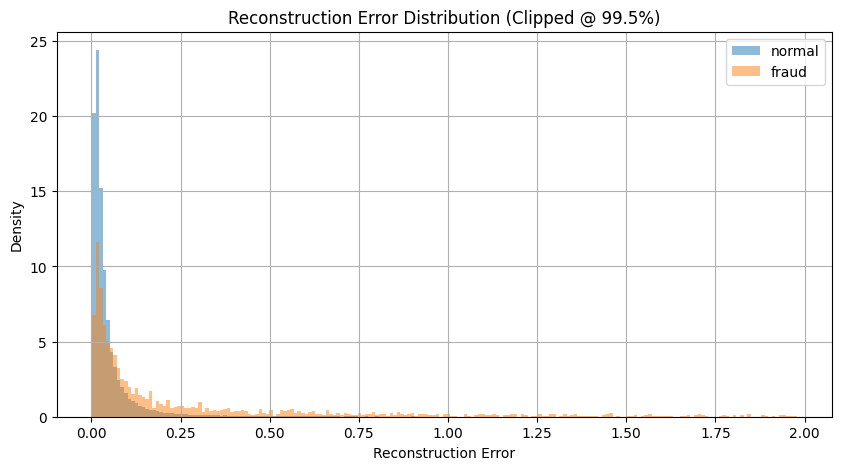

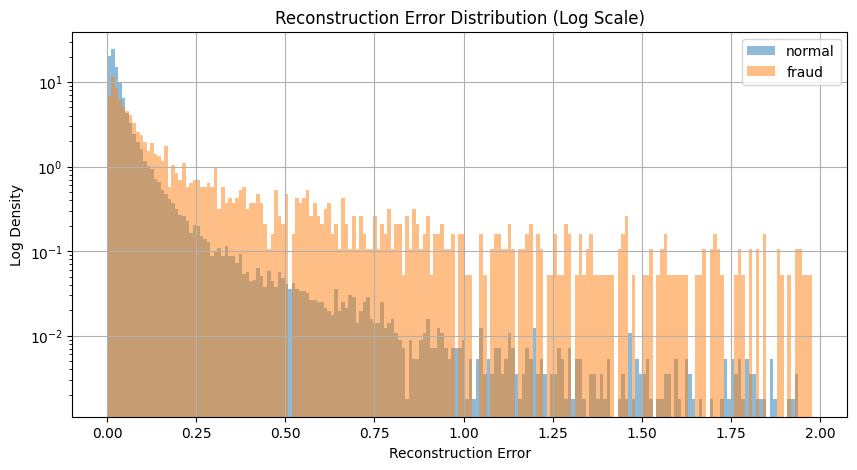

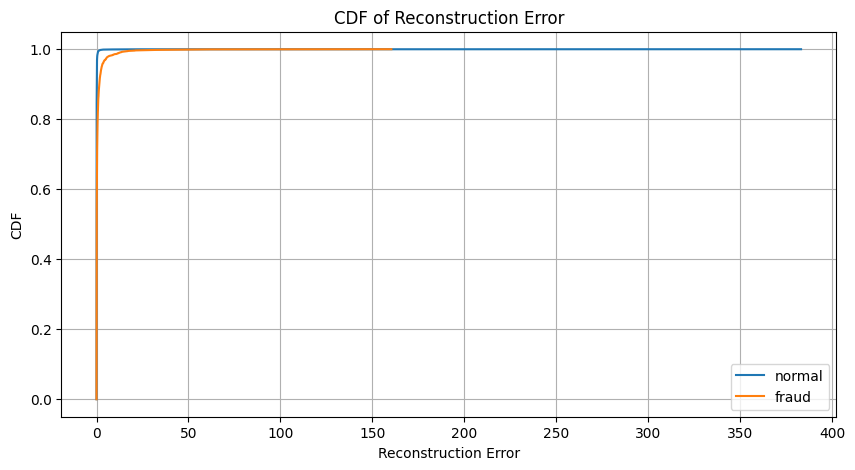

In [19]:
import matplotlib.pyplot as plt

# Combine to define consistent bins
all_errors = np.concatenate([normal, fraud])

bins = np.linspace(all_errors.min(), np.percentile(all_errors, 99.5), 200)

# normal hist
plt.figure(figsize=(10, 5))

plt.hist(normal, bins=bins, alpha=0.5, label="normal", density=True)
plt.hist(fraud, bins=bins, alpha=0.5, label="fraud", density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution (Clipped @ 99.5%)")
plt.legend()
plt.grid(True)

plt.show()

# log hist
plt.figure(figsize=(10, 5))

plt.hist(normal, bins=bins, alpha=0.5, label="normal", density=True)
plt.hist(fraud, bins=bins, alpha=0.5, label="fraud", density=True)

plt.yscale("log")  

plt.xlabel("Reconstruction Error")
plt.ylabel("Log Density")
plt.title("Reconstruction Error Distribution (Log Scale)")
plt.legend()
plt.grid(True)

plt.show()

# cdf
def plot_cdf(data, label):
    sorted_data = np.sort(data)
    y = np.linspace(0, 1, len(data))
    plt.plot(sorted_data, y, label=label)

plt.figure(figsize=(10, 5))

plot_cdf(normal, "normal")
plot_cdf(fraud, "fraud")

plt.xlabel("Reconstruction Error")
plt.ylabel("CDF")
plt.title("CDF of Reconstruction Error")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Try a VAE model for the hardest of fraud cases. Intended for use in the ensemble

def train_vae_epoch(
    model,
    loader,
    optimizer,
    recon_weight: float = 1.0,
    kl_weight: float = 1e-3,
):
    model.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            x, _ = batch
        else:
            x = batch

        x = x.to(DEVICE).float()

        optimizer.zero_grad()

        x_hat, mu, logvar, z = model(x)

        loss, recon, kl = vae_loss(
            x=x,
            x_hat=x_hat,
            mu=mu,
            logvar=logvar,
            recon_weight=recon_weight,
            kl_weight=kl_weight,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = max(len(loader), 1)
    return {
        "loss": total_loss / n,
        "recon": total_recon / n,
        "kl": total_kl / n,
    }

@torch.no_grad()
def eval_vae_separation(model, loader, score_type: str = "recon"):
    model.eval()

    scores = []
    labels = []

    for x, y in loader:
        x = x.to(DEVICE).float()

        if score_type == "recon":
            score = model.reconstruction_error(x)
        elif score_type == "kl":
            score = model.kl_per_sample(x)
        elif score_type == "recon_plus_kl":
            score = model.reconstruction_error(x) + model.kl_per_sample(x)
        else:
            raise ValueError("score_type must be 'recon', 'kl', or 'recon_plus_kl'")

        scores.append(score.cpu())
        labels.append(y.cpu())

    scores = torch.cat(scores)
    labels = torch.cat(labels)

    fraud = scores[labels == 1]
    normal = scores[labels == 0]

    return {
        "normal_mean": normal.mean().item(),
        "fraud_mean": fraud.mean().item(),
        "separation_ratio": (fraud.mean() / (normal.mean() + 1e-8)).item(),
    }

def save_vae(model, path):
    torch.save(
        {
            "state_dict": model.state_dict(),
            "input_dim": model.input_dim,
            "latent_dim": model.latent_dim,
            "hidden_dims": model.hidden_dims,
            "noise_std": model.noise_std,
            "use_norm": model.use_norm,
        },
        path,
)

In [ ]:
vae = EnsembleVAE(
    input_dim=input_dim,
    latent_dim=32,
    hidden_dims=[256, 128],
    noise_std=0.01,
    use_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(vae.parameters(), lr=1e-3, weight_decay=1e-4)

In [16]:


for epoch in range(30):
    stats = train_vae_epoch(
        model=vae,
        loader=train_loader,
        optimizer=optimizer,
        recon_weight=1.0,
        kl_weight=1e-5,
    )

    sep_recon = eval_vae_separation(vae, val_loader, score_type="recon")
    sep_kl = eval_vae_separation(vae, val_loader, score_type="kl")

    print(
        f"Epoch {epoch+1:02d} | "
        f"loss={stats['loss']:.6f} | "
        f"recon={stats['recon']:.6f} | "
        f"kl={stats['kl']:.6f} | "
        f"recon_ratio={sep_recon['separation_ratio']:.3f} | "
        f"kl_ratio={sep_kl['separation_ratio']:.3f}"
    )

Epoch 01 | loss=0.068181 | recon=0.066316 | kl=186.466690 | recon_ratio=10.547 | kl_ratio=1.693
Epoch 02 | loss=0.050624 | recon=0.048767 | kl=185.656736 | recon_ratio=14.151 | kl_ratio=1.691
Epoch 03 | loss=0.072002 | recon=0.070127 | kl=187.496332 | recon_ratio=14.578 | kl_ratio=1.749
Epoch 04 | loss=0.059446 | recon=0.057490 | kl=195.575884 | recon_ratio=15.302 | kl_ratio=1.697
Epoch 05 | loss=0.057972 | recon=0.056007 | kl=196.513080 | recon_ratio=16.004 | kl_ratio=1.826
Epoch 06 | loss=0.065779 | recon=0.063891 | kl=188.813125 | recon_ratio=14.517 | kl_ratio=1.684
Epoch 07 | loss=0.059968 | recon=0.058130 | kl=183.727723 | recon_ratio=14.736 | kl_ratio=1.790
Epoch 08 | loss=0.068629 | recon=0.066587 | kl=204.260322 | recon_ratio=15.969 | kl_ratio=1.703
Epoch 09 | loss=0.048975 | recon=0.046737 | kl=223.866393 | recon_ratio=13.453 | kl_ratio=1.489
Epoch 10 | loss=0.052459 | recon=0.050109 | kl=235.001481 | recon_ratio=14.612 | kl_ratio=1.434
Epoch 11 | loss=0.081246 | recon=0.07874

In [17]:
@torch.no_grad()
def summarize_scores(name, scores):
    scores = scores.cpu()
    print(f"{name}:")
    print(f"  mean : {scores.mean().item():.6f}")
    print(f"  p50  : {scores.median().item():.6f}")
    print(f"  p75  : {torch.quantile(scores, 0.75).item():.6f}")
    print(f"  p90  : {torch.quantile(scores, 0.90).item():.6f}")
    print(f"  p95  : {torch.quantile(scores, 0.95).item():.6f}")

@torch.no_grad()
def collect_vae_scores(model, loader, DEVICE):
    model.eval()

    recon_all = []
    kl_all = []
    y_all = []

    for x, y in loader:
        x = x.to(DEVICE).float()

        recon = model.reconstruction_error(x)
        kl = model.kl_per_sample(x)

        recon_all.append(recon.cpu())
        kl_all.append(kl.cpu())
        y_all.append(y.cpu())

    recon = torch.cat(recon_all)
    kl = torch.cat(kl_all)
    y = torch.cat(y_all)

    return recon, kl, y

def get_false_negative_mask(probs, labels, threshold):
    preds = (probs >= threshold).long()
    fn_mask = (labels == 1) & (preds == 0)
    return fn_mask

In [18]:
recon, kl, y = collect_vae_scores(vae, test_loader, DEVICE)


normal = y == 0
fraud = y == 1

summarize_scores("Normal (Recon)", recon[normal])
summarize_scores("Fraud (Recon)", recon[fraud])

summarize_scores("Normal (KL)", kl[normal])
summarize_scores("Fraud (KL)", kl[fraud])

Normal (Recon):
  mean : 0.089182
  p50  : 0.027498
  p75  : 0.054065
  p90  : 0.119233
  p95  : 0.197044
Fraud (Recon):
  mean : 0.758219
  p50  : 0.099933
  p75  : 0.376759
  p90  : 1.157867
  p95  : 2.215688
Normal (KL):
  mean : 6.933538
  p50  : 4.884785
  p75  : 5.963099
  p90  : 8.659757
  p95  : 11.693428
Fraud (KL):
  mean : 14.383620
  p50  : 7.130115
  p75  : 12.319134
  p90  : 23.642269
  p95  : 37.755795


Much better than the normal autoencoder, already we can see clean seperation at every percentile level.

In [19]:
save_vae(vae, "checkpoints/ensemble_vae2.pt")